# Explore Chl a bit

In [1]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting
from ocpy.utils import coords as ocpy_coords
from ocpy.water import scattering

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Locals
from grab_pace_granules import load_from_json
import fitting as m_fitting
import grab_pace_granules

/home/xavier/Oceanography/python/ocpy/ocpy/ph/absorption.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/xavier/miniconda3/envs/ocean13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load up

In [2]:
match_file = 'matched_argo_bgc_profiles_bbp.csv'
# Load up Argo profiles, already matched to PACE
matched = pandas.read_csv(match_file)
matched.head()

,cruise,filename,profile,lat,lon,time,solar_angle,pace_ids,closest_id,closest_file,...,Bnw_hsig,beta,aph,FLH,GIOP_bbp_700,GIOP_bbp_442,GIOP_bbp_s,GIOP_Y,GIOP_Chl,GIOP_CDOM
0,1902368,1902368QC.nc,13,56.348,-147.356,2024-07-09 04:35:00.000002048+00:00,13.134825,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI.20240708T202028.L2.OC_AOP.V3_0.nc,...,0.000077,1.930553,0.041115,-32767.0,0.001041,0.002970,1.513135,1.683451,0.024168,0.047098
1,1902369,1902369QC.nc,4,45.006,-133.357,2024-05-09 22:07:00.000001536+00:00,58.276589,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,...,0.000039,1.874987,0.005746,-32767.0,0.000353,0.001140,1.886365,2.120493,0.008773,0.047097
2,1902369,1902369QC.nc,5,45.020,-133.356,2024-05-10 09:02:59.999999488+00:00,-27.116450,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,...,0.000037,1.868712,0.006338,-32767.0,0.000336,0.001135,1.886341,2.118525,0.008337,0.047377
3,1902369,1902369QC.nc,6,45.020,-133.354,2024-05-10 19:52:59.999998464+00:00,60.421381,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,...,0.000037,1.868712,0.006338,-32767.0,0.000336,0.001135,1.886341,2.118525,0.008337,0.047377
4,1902369,1902369QC.nc,7,45.038,-133.348,2024-05-11 08:18:59.999995904+00:00,-26.535430,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_0.nc,...,0.000043,1.817395,0.006617,-32767.0,0.000416,0.001265,1.869460,2.115456,0.010317,0.047969


## Checks

In [26]:
gd_FLH = matched.FLH > -30000.
gd_GIOP =  matched.GIOP_bbp_442 > -20000.
#
all_gd = gd_FLH & gd_GIOP

# BING vs. GIOP

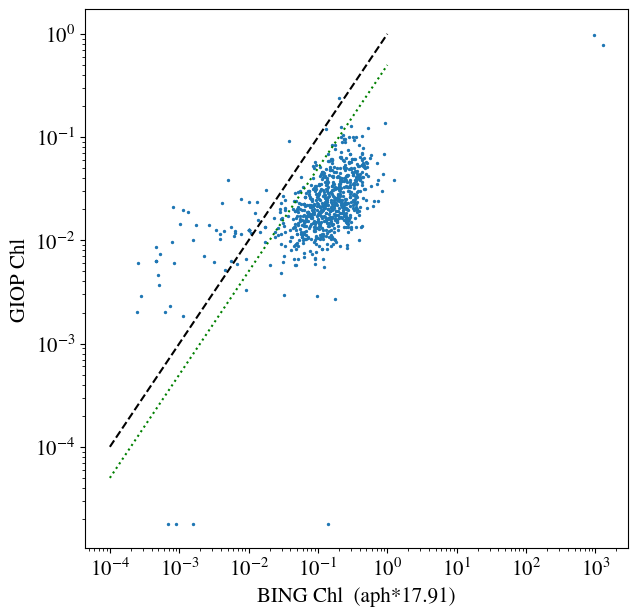

In [23]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#ax = sns.scatterplot(matched[gd_GIOP], x='aph', y='GIOP_Chl', s=5.)
aph_to_Chl = 1/0.05582
ax.scatter(matched[gd_GIOP].aph*aph_to_Chl, 
    matched[gd_GIOP].GIOP_Chl, s=2.)
xmin, xmax = 1e-4, 1.0
#ax.set_xlim(xmin, xmax)
ax.set_xscale('log')
ax.set_yscale('log')
# 1-1 line
ax.plot([xmin, xmax], np.array([xmin,xmax]), 'k--')
# 1/2
xval = np.linspace(xmin, xmax, 10000)
yval = xval/2
ax.plot(xval, yval, 'g:')
#
plotting.set_fontsize(ax, 15.)
# Relabel
ax.set_xlabel(f'BING Chl  (aph*{aph_to_Chl:0.2f})')
ax.set_ylabel('GIOP Chl')
#
plt.show()

# FLH

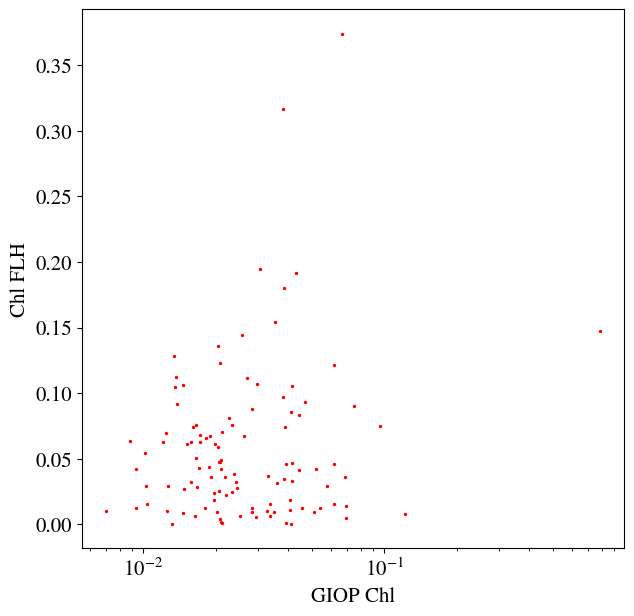

In [27]:

fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#ax = sns.scatterplot(matched[gd_GIOP], x='aph', y='GIOP_Chl', s=5.)
ax.scatter(matched[all_gd].GIOP_Chl, 
    matched[all_gd].FLH, s=2., color='r')
#xmin, xmax = 1e-4, 1.0
#ax.set_xlim(xmin, xmax)
ax.set_xscale('log')
#ax.set_yscale('log')
#
plotting.set_fontsize(ax, 15.)
# Relabel
ax.set_xlabel('GIOP Chl')
ax.set_ylabel('Chl FLH')
#
plt.show()